<a href="https://colab.research.google.com/github/TienNguyen0712/hybrid-llm-tabular-pipeline-for-icu-mortality-prediction/blob/main/notebooks/predict_mortality_using_mimic_iv_baseline_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Xây dựng mô hình dự đoán tỷ lệ tử vong của ICU từ MIMIC-IV (BaseLine2)**

**Mục tiêu:**

Notebook này thực hiện xây dựng một mô hình dự đoán tỷ lệ tử vong từ bảng MIMIC bằng các mô hình học máy. Nhằm tạo ra một chuẩn dữ liệu để so sánh với các kỹ thuật khác trong tương lai (nếu có)

**Bộ dữ liệu**

MIMIC-IV là cơ sở dữ liệu lớn gồm các bảng về thông tin bệnh nhân, lâm sàng, các thủ thuật, v...

Lý do chọn bộ dữ liệu này do tính phức tạp, sát với dữ liệu thực tế, việc xử lý dữ liệu này là một trong những bước khó khắn, ...

- 2 module chính được sử dụng trong notebook này chính là `hosp` và `icu`. Chi tiết các bảng lựa chọn sẽ được mô tả ở dưới


## **1. Nạp thư viện và dữ liệu cần thiết**

In [1]:
# Bỏ comment nếu chạy trên Google Colab
from google.colab import drive
drive.mount('/content/drive')
!pip install tableone pyarrow seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import OrderedDict
import gc
import warnings
warnings.filterwarnings('ignore')

from typing import List, Tuple, Dict, Optional

# Cài đặt style biểu đồ chuyên nghiệp
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_style("whitegrid")
print("✓ Libraries loaded")


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.4 MB/s eta 0:00:00
✓ Libraries loaded


Nếu thực hiện chạy trên dữ liệu thực thì mở cmt code dưới

In [3]:
# DATA_DIR = "/content/drive/MyDrive/NCKH-DDU1231/physionet.org/mimiciv/3.1"  # Google Colab dữ liệu chính
# HOURS = 48
# TEST_SIZE = 0.2
# VAL_SIZE = 0.1

# import os
# def load(folder, name):
#     path = os.path.join(DATA_DIR, folder, name)
#     if os.path.exists(path):
#         df = pd.read_csv(path)
#         print(f"  ✓ {folder}/{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
#         return df
#     else:
#         print(f"  ✗ {folder}/{name}: KHÔNG TÌM THẤY")
#         return pd.DataFrame()


Thực hiện chạy trên dữ liệu demo của mimic chạy code dưới

In [2]:
DATA_DIR = "/content/drive/MyDrive/NCKH-DDU1231/mimic-iv-clinical-database-demo-2.2/mimic-iv-clinical-database-demo-2.2"  # Google Colab
HOURS = 48
TEST_SIZE = 0.2
VAL_SIZE = 0.1

import os
def load(folder, name):
    path = os.path.join(DATA_DIR, folder, name)
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"  ✓ {folder}/{name}: {df.shape[0]:,} rows × {df.shape[1]} cols")
        return df
    else:
        print(f"  ✗ {folder}/{name}: KHÔNG TÌM THẤY")
        return pd.DataFrame()

## **2. Tiền xử lý dữ liệu trước khi chia huấn luyện**

### **2.1. Xây dựng tập cohort**

Cohort được xây dựng bám sát theo các tiêu chí như sau:
- Phải là người trưởng thành (anchor_age > 18)

In [4]:
def build_and_val_icu_cohort(patients_df: pd.DataFrame, admissions_df: pd.DataFrame, icustays_df: pd.DataFrame) -> pd.DataFrame:
  # Chuyển đổi định dạng mốc thời gian sang Datetime
  time_cols = {
      'icustays_df': ['intime', 'outtime'],
      'admissions_df': ['admittime', 'dischtime'],
      'patients_df' : []
  }

  for col in time_cols['icustays_df']:
        icustays_df[col] = pd.to_datetime(icustays_df[col])
  for col in time_cols['admissions_df']:
        admissions_df[col] = pd.to_datetime(admissions_df[col])
  # Inner Join với admission
  cohort = icustays_df.merge(
  admissions_df[["subject_id", "hadm_id", "admittime", "dischtime",
                 "deathtime", "hospital_expire_flag"]],
          on=['subject_id', 'hadm_id'],
          how='inner'
      )
  # Inner join với patients
  cohort = cohort.merge(
          patients_df[["subject_id", "gender", "anchor_age", "dod"]],
          on='subject_id',
          how='inner'
      )

  initial_count = len(cohort)
  print(f"Tổng số lượt ICU ban đầu: {initial_count:,}")

  # Áp dụng các tiêu chí lọc

  cohort = cohort[cohort["anchor_age"] >= 18].copy() # Bệnh nhân trên 18 tuổi
  cohort["Outcome"]   = cohort["hospital_expire_flag"].astype(int) # Chuyển biến outcome về dạng nhị phân (0/1)
  cohort["Sex"]       = (cohort["gender"] == "M").astype(int) # Chuyển biến giới tính về dạng nhị phân (0/1)
  cohort["LOS_hours"] = cohort["los"].astype(float) * 24 # Tạo biến los - giờ nằm icu

  cohort = cohort.rename(columns={
        "subject_id": "PatientID", "hadm_id": "AdmissionID", # Đổi mã bệnh nhân,  mã lần nhập viện
        "stay_id": "StayID",       "intime":  "ICUInTime", # Đổi mã nằm icu, thời gian vào ICU
        "outtime": "ICUOutTime",   "anchor_age": "Age", # Đổi thời gian ra icu, tuổi bệnh nhân
    })[["PatientID", "AdmissionID", "StayID",
        "ICUInTime", "ICUOutTime",
        "Age", "Sex", "Outcome", "LOS_hours"]].reset_index(drop=True) # Lấy các đặc trưng cần lấy

  print(f"  ICU stays      : {len(cohort):,}")
  print(f"  Unique patients: {cohort['PatientID'].nunique():,}")
  print(f"  Mortality      : {cohort['Outcome'].sum():,}  "
        f"({cohort['Outcome'].mean()*100:.1f}%)")

  return cohort


In [5]:
print("Loading core tables...")
patients   = load("hosp", "patients.csv.gz")      # Thông tin bệnh nhân
admissions = load("hosp", "admissions.csv.gz")    # Thông tin nhập viện
icustays   = load("icu",  "icustays.csv.gz")      # Thông tin lần nằm

cohort = build_and_val_icu_cohort(patients, admissions, icustays)

Loading core tables...
  ✓ hosp/patients.csv.gz: 100 rows × 6 cols
  ✓ hosp/admissions.csv.gz: 275 rows × 16 cols
  ✓ icu/icustays.csv.gz: 140 rows × 8 cols
Tổng số lượt ICU ban đầu: 140
  ICU stays      : 140
  Unique patients: 100
  Mortality      : 20  (14.3%)


In [6]:
cohort.head()

,PatientID,AdmissionID,StayID,ICUInTime,ICUOutTime,Age,Sex,Outcome,LOS_hours
0,10018328,23786647,31269608,2154-04-24 23:03:44,2154-05-02 15:55:21,83,0,0,184.860278
1,10020187,24104168,37509585,2169-01-15 04:56:00,2169-01-20 15:47:50,63,0,0,130.863889
2,10020187,26842957,32554129,2170-02-24 18:18:46,2170-02-25 15:15:26,63,0,0,20.944444
3,10012853,27882036,31338022,2176-11-26 02:34:49,2176-11-29 20:58:54,91,0,0,90.401389
4,10020740,25826145,32145159,2150-06-03 20:12:32,2150-06-04 21:05:58,56,1,0,24.890556


In [7]:
cohort.isna().sum()

,0
PatientID,0
AdmissionID,0
StayID,0
ICUInTime,0
ICUOutTime,0
Age,0
Sex,0
Outcome,0
LOS_hours,0


In [8]:
cohort.columns

Index(['PatientID', 'AdmissionID', 'StayID', 'ICUInTime', 'ICUOutTime', 'Age',
       'Sex', 'Outcome', 'LOS_hours'],
      dtype='object')

## **3. Xây dựng các bảng đặc trưng thực hiện tiền xử lý cho dữ liệu huấn luyện**

In [11]:
# Mapping & Lists
# Ngưỡng cho phép của các chỉ số
VALID_RANGE = {
    "HR": (10, 300), "RR": (2, 80), "Temp_C": (25, 45), "Temp_F": (77, 113), "SBP": (30, 300), "DBP": (10, 200), "MBP": (20, 250), "SpO2": (50, 100),
    "GCS_total": (3, 15), "WBC": (0.1, 500), "HCT": (5, 70), "PLT": (1, 3000), "pH": (6.5, 8.5), "FiO2": (0.1, 1.05), "PaO2": (10, 700), "PaCO2": (10, 200),
    "HCO3": (5, 60), "CKMB": (0, 10000), "BNP": (1, 50000), "AST": (1, 50000), "ALT": (1, 50000), "Bili_total": (0.1, 100), "Bili_direct": (0.1, 100),
    "DDimer": (0.1, 100000), "BUN": (1, 500), "Creatinine": (0.1, 50), "Cortisol": (0.1, 200), "Na": (100, 180), "K": (1, 10), "Cl": (70, 150),
    "Mg": (0.5, 10), "Glucose": (10, 2000), "Height": (50, 250), "Weight": (10, 400), "WBC_lab": (0.1, 500), "HCT_lab": (5, 70), "PLT_lab": (1, 3000),
    "pH_lab": (6.5, 8.5), "PaO2_lab": (10, 700), "PaCO2_lab": (10, 200), "HCO3_lab": (5, 60), "Creatinine_lab": (0.1, 50), "BUN_lab": (1, 500),
    "Albumin_lab": (0.5, 8), "Lactate_lab": (0.1, 30), "CRP_lab": (0, 500), "Ca_lab": (3, 20), "Na_lab": (100, 180), "K_lab": (1, 10), "Cl_lab": (70, 150), "Mg_lab": (0.5, 10),
}

**Các đặc trưng được đề cập như:**



-  Định danh & Thời gian (Identifiers & Time)

    - `PatientID` — Mã định danh bệnh nhân

    - `AdmissionID` — Mã định danh đợt nhập viện

    - `hour_bucket` — Khoảng thời gian theo giờ

- Nhân khẩu học & Thể trạng (Demographics & Physical Characteristics)

  - `Height` — Chiều cao

  - `Weight` — Cân nặng

- Dấu hiệu sinh tồn & Tri giác (Vital Signs & Neurological Status)

  - `HR` *(Heart Rate)* — Nhịp tim

  - `RR` *(Respiratory Rate)* — Nhịp thở

  - `Temp_C` *(Body Temperature)* — Nhiệt độ cơ thể (°C)

  - `SBP` *(Systolic Blood Pressure)* — Huyết áp tâm thu

  - `DBP` *(Diastolic Blood Pressure)* — Huyết áp tâm trương

  - `MBP` *(Mean Blood Pressure)* — Huyết áp trung bình

  - `SpO2` *(Oxygen Saturation)* — Độ bão hòa oxy trong máu ngoại vi

  - `GCS_total` *(Glasgow Coma Scale)* — Tổng điểm tri giác Glasgow

- Huyết học (Hematology / CBC)

  - `WBC` *(White Blood Cells)* — Số lượng bạch cầu

  - `HCT` *(Hematocrit)* — Tỷ lệ thể tích hồng cầu

  - `PLT` *(Platelets)* — Số lượng tiểu cầu

- Khí máu động mạch & Hô hấp (Arterial Blood Gas / ABG & Respiratory)

  - `pH` — Độ pH trong máu

  - `FiO2` *(Fraction of Inspired Oxygen)* — Tỷ lệ oxy trong khí hít vào

  - `PaO2` *(Partial Pressure of Oxygen)* — Áp suất riêng phần Oxy trong máu động mạch

  - `PaCO2` *(Partial Pressure of Carbon Dioxide)* — Áp suất riêng phần CO2 trong máu động mạch

  - `HCO3` *(Bicarbonate)* — Nồng độ Bicarbonate trong máu

- Điện giải & Chuyển hóa (Electrolytes & Metabolic Panel)

  - `Na` *(Sodium)* — Nồng độ Natri

  - `K` *(Potassium)* — Nồng độ Kali

  - `Cl` *(Chloride)* — Nồng độ Clo

  - `Mg` *(Magnesium)* — Nồng độ Magie

  - `Glucose` — Đường huyết

- Chức năng thận (Renal Function Panel)

  - `BUN` *(Blood Urea Nitrogen)* — Nồng độ Urê trong máu

  - `Creatinine` — Nồng độ Creatinine trong máu

- Chức năng gan (Hepatic Function Panel)

  - `AST` *(Aspartate Aminotransferase)* — Men gan AST

  - `ALT` *(Alanine Aminotransferase)* — Men gan ALT

  - `Bili_total` *(Total Bilirubin)* — Bilirubin toàn phần

  - `Bili_direct` *(Direct Bilirubin)* — Bilirubin trực tiếp

- Chỉ số tim mạch (Cardiac Markers)

  - `CKMB` *(Creatine Kinase-MB)* — Enzyme tim CK-MB

  - `BNP` *(Brain Natriuretic Peptide)* — Peptide bài niệu tuýp B

- Đông máu & Nội tiết (Coagulation & Endocrine Markers)

  - `DDimer` *(D-Dimer)* — Sản phẩm thoái biến Fibrin (đánh giá huyết khối)

  - `Cortisol` — Nồng độ hormone Cortisol trong máu



In [10]:
from typing import Dict, Tuple, List
from sklearn.model_selection import train_test_split

### **3.1. Xây dựng bảng chart vitals từ `chartevent`**

Kết hợp với bảng cohort với cửa số được lấy trong vòng 24h khi nằm ở icu
- intime <= charttime <= intime + 24h
- Lọc các chỉ số theo mã id hợp lệ rồi học các giá trị ngoại lai
- Thực hiện sinh thêm các đặc trưng mới với các chỉ số phức tạp

In [12]:
CHART_ITEM2VAR = {
    220045: "HR", 220210: "RR", 224690: "RR", 224422: "RR",
    223761: "Temp_F", 223762: "Temp_C", 220179: "SBP", 220050: "SBP",
    220180: "DBP", 220051: "DBP", 220052: "MBP", 220181: "MBP", 220277: "SpO2",
    220739: "GCS_eye", 223901: "GCS_motor", 223900: "GCS_verbal",
    220546: "WBC", 220545: "HCT", 227457: "PLT", 220274: "pH", 223835: "FiO2",
    220224: "PaO2", 220235: "PaCO2", 227443: "HCO3", 227445: "CKMB", 227446: "BNP",
    220587: "AST", 220644: "ALT", 225690: "Bili_total", 225651: "Bili_direct",
    225636: "DDimer", 225624: "BUN", 220615: "Creatinine_raw", 227463: "Cortisol",
    220645: "Na", 227442: "K", 220602: "Cl", 220635: "Mg", 220621: "Glucose",
    226707: "Height_in", 226730: "Height_cm", 226512: "Weight_kg", 226531: "Weight_lbs",
}

GCS_EYE_MAP = {"None": 0, "1 No Response": 1, "2 To pain": 2, "To Pain": 2, "3 To speech": 3, "To Speech": 3, "4 Spontaneously": 4, "Spontaneously": 4}
GCS_MOTOR_MAP = {"1 No Response": 1, "No response": 1, "2 Abnorm extensn": 2, "Abnormal extension": 2, "3 Abnorm flexion": 3, "Abnormal Flexion": 3, "4 Flex-withdraws": 4, "Flex-withdraws": 4, "5 Localizes Pain": 5, "Localizes Pain": 5, "6 Obeys Commands": 6, "Obeys Commands": 6}
GCS_VERBAL_MAP = {"No Response-ETT": 1, "No Response": 1, "1 No Response": 1, "1.0 ET/Trach": 1, "2 Incomp sounds": 2, "Incomprehensible sounds": 2, "3 Inapprop words": 3, "Inappropriate Words": 3, "4 Confused": 4, "Confused": 4, "5 Oriented": 5, "Oriented": 5}

CHART_FEATURES = ["HR", "RR", "Temp_C", "SBP", "DBP", "MBP", "SpO2", "GCS_total", "WBC", "HCT", "PLT", "pH", "FiO2", "PaO2", "PaCO2", "HCO3", "CKMB", "BNP", "AST", "ALT", "Bili_total", "Bili_direct", "DDimer", "BUN", "Creatinine", "Cortisol", "Na", "K", "Cl", "Mg", "Glucose", "Height", "Weight"]

#### **Cho demo Data**

In [24]:
def process_chartevents(data_dir, cohort, hours=48):
    print(f"Đang xử lý chartevents...")

    # Chuẩn bị dict tra cứu
    stay2intime = cohort.set_index("StayID")["ICUInTime"].to_dict()
    valid_stays = set(cohort["StayID"].tolist())
    valid_items = set(CHART_ITEM2VAR.keys())

    # Đọc toàn bộ file chartevents.csv
    file_path = os.path.join(data_dir, "icu", "chartevents.csv.gz")
    df = pd.read_csv(
        file_path,
        usecols=["subject_id", "hadm_id", "stay_id", "charttime", "itemid", "value", "valuenum"], # Lấy các cột trong chartevents cần sử dụng
        low_memory=False
    )

    # Lọc theo StayID và ItemID
    df = df[df["stay_id"].isin(valid_stays) & df["itemid"].isin(valid_items)].copy()
    if df.empty:
        print("Không tìm thấy dữ liệu phù hợp!")
        return pd.DataFrame(columns=["PatientID", "AdmissionID", "hour_bucket"] + CHART_FEATURES)

    # Tính toán thời gian & Lọc theo số giờ (hours)
    df["charttime"]  = pd.to_datetime(df["charttime"]) # Chuyển về kiểu thời gian
    df["icu_intime"] = df["stay_id"].map(stay2intime)  # Map với stay_id dể khớp với stay trong cohort
    # Giờ được phép lấy = Thời gian lẫy mãu - thời gian vào icu
    df["hours_in"]   = (df["charttime"] - df["icu_intime"]).dt.total_seconds() / 3600
    df = df[(df["hours_in"] >= 0) & (df["hours_in"] < hours)] # ĐK: 0 <= hours_in < hours: 48

    # Phân nhóm giờ và ánh xạ tên biến
    df["Variable"]    = df["itemid"].map(CHART_ITEM2VAR)  # Mạp các biến theo id
    df["hour_bucket"] = df["hours_in"].astype(int).clip(0, hours - 1) # Chia từ nhóm 0 -> nhóm thứ hours - 1 (48 - 1)

    # Chuyển đổi đơn vị
    m = df["Variable"] == "Temp_F"
    df.loc[m, "valuenum"] = (pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") - 32) * 5.0 / 9.0
    df.loc[m, "Variable"] = "Temp_C"

    m = df["Variable"] == "Weight_lbs"
    df.loc[m, "valuenum"] = pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") * 0.453592
    df.loc[m, "Variable"] = "Weight"
    df.loc[df["Variable"] == "Weight_kg", "Variable"] = "Weight"

    m = df["Variable"] == "Height_in"
    df.loc[m, "valuenum"] = pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") * 2.54
    df.loc[m, "Variable"] = "Height"
    df.loc[df["Variable"] == "Height_cm", "Variable"] = "Height"

    m = df["Variable"] == "Creatinine_raw"
    df.loc[m, "valuenum"] = pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") / 88.42
    df.loc[m, "Variable"] = "Creatinine"

    for var, mapping in [("GCS_eye", GCS_EYE_MAP), ("GCS_motor", GCS_MOTOR_MAP), ("GCS_verbal", GCS_VERBAL_MAP)]:
        m = df["Variable"] == var
        df.loc[m, "valuenum"] = df.loc[m, "value"].map(mapping)

    # Ép kiểu số & Lọc dữ liệu rác
    df["valuenum"] = pd.to_numeric(df["valuenum"], errors="coerce")
    df = df.dropna(subset=["valuenum"]).drop(columns=["itemid", "value"])

    # Lọc Outliers
    if VALID_RANGE is not None:
        for feat, (lo, hi) in VALID_RANGE.items():
            m = df["Variable"] == feat
            if m.any():
                df = df[~(m & ((df["valuenum"] < lo) | (df["valuenum"] > hi)))]

    # Pivot Wide
    wide = (
        df.groupby(["subject_id", "hadm_id", "hour_bucket", "Variable"])["valuenum"]
        .mean()
        .reset_index()
        .pivot_table(index=["subject_id", "hadm_id", "hour_bucket"], columns="Variable", values="valuenum")
        .reset_index()
    )

    wide.columns.name = None
    wide = wide.rename(columns={"subject_id": "PatientID", "hadm_id": "AdmissionID"})

    # Bổ sung các cột thiếu bằng NaN
    for col in CHART_FEATURES:
        if col not in wide.columns: wide[col] = np.nan

    return wide[["PatientID", "AdmissionID", "hour_bucket"] + CHART_FEATURES]

In [22]:
chart = process_chartevents(DATA_DIR, cohort, HOURS)
chart.head()

Đang xử lý chartevents...


,PatientID,AdmissionID,hour_bucket,HR,RR,Temp_C,SBP,DBP,MBP,SpO2,...,BUN,Creatinine,Cortisol,Na,K,Cl,Mg,Glucose,Height,Weight
0,10000032,29079034,0,92.0,22.5,37.055556,89.5,53.5,61.5,97.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.326426
1,10000032,29079034,1,94.0,23.0,NaN,88.0,56.0,64.0,97.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10000032,29079034,2,105.0,21.0,NaN,91.0,55.0,64.0,94.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10000032,29079034,3,97.0,20.0,37.055556,95.0,58.0,67.0,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10000032,29079034,4,100.0,21.0,NaN,86.0,53.0,60.0,95.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
chart.columns

Index(['PatientID', 'AdmissionID', 'hour_bucket', 'HR', 'RR', 'Temp_C', 'SBP',
       'DBP', 'MBP', 'SpO2', 'GCS_total', 'WBC', 'HCT', 'PLT', 'pH', 'FiO2',
       'PaO2', 'PaCO2', 'HCO3', 'CKMB', 'BNP', 'AST', 'ALT', 'Bili_total',
       'Bili_direct', 'DDimer', 'BUN', 'Creatinine', 'Cortisol', 'Na', 'K',
       'Cl', 'Mg', 'Glucose', 'Height', 'Weight'],
      dtype='object')

#### **Cho Data thực**

In [27]:
# def process_chartevents(data_dir, cohort, hours=48):
#     print("STEP 2: Xử lý chartevents...")
#     stay2intime = cohort.set_index("StayID")["ICUInTime"].to_dict()
#     valid_stays = set(cohort["StayID"].tolist())
#     valid_items = set(CHART_ITEM2VAR.keys())

#     chunks = []
#     for chunk in tqdm(pd.read_csv(os.path.join(data_dir, "icu", "chartevents.csv"), usecols=["subject_id", "hadm_id", "stay_id", "charttime", "itemid", "value", "valuenum"], chunksize=10_000_000, low_memory=False), desc="chartevents"):
#         chunk = chunk[chunk["stay_id"].isin(valid_stays) & chunk["itemid"].isin(valid_items)].copy()
#         if chunk.empty: continue

#         chunk["charttime"]  = pd.to_datetime(chunk["charttime"])
#         chunk["icu_intime"] = chunk["stay_id"].map(stay2intime)
#         chunk["hours_in"]   = (chunk["charttime"] - chunk["icu_intime"]).dt.total_seconds() / 3600
#         chunk = chunk[(chunk["hours_in"] >= 0) & (chunk["hours_in"] < hours)]
#         if chunk.empty: continue

#         chunk["Variable"]    = chunk["itemid"].map(CHART_ITEM2VAR)
#         chunk["hour_bucket"] = chunk["hours_in"].astype(int).clip(0, hours - 1)
#         chunks.append(chunk[["subject_id", "hadm_id", "stay_id", "hour_bucket", "Variable", "itemid", "value", "valuenum"]])

#     df = pd.concat(chunks, ignore_index=True)
#     del chunks; gc.collect()

#     # Chuyển đổi đơn vị
#     m = df["Variable"] == "Temp_F"
#     df.loc[m, "valuenum"] = (pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") - 32) * 5.0 / 9.0
#     df.loc[m, "Variable"] = "Temp_C"

#     m = df["Variable"] == "Weight_lbs"
#     df.loc[m, "valuenum"] = pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") * 0.453592
#     df.loc[m, "Variable"] = "Weight"
#     df.loc[df["Variable"] == "Weight_kg", "Variable"] = "Weight"

#     m = df["Variable"] == "Height_in"
#     df.loc[m, "valuenum"] = pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") * 2.54
#     df.loc[m, "Variable"] = "Height"
#     df.loc[df["Variable"] == "Height_cm", "Variable"] = "Height"

#     m = df["Variable"] == "Creatinine_raw"
#     df.loc[m, "valuenum"] = pd.to_numeric(df.loc[m, "valuenum"], errors="coerce") / 88.42
#     df.loc[m, "Variable"] = "Creatinine"

#     for var, mapping in [("GCS_eye", GCS_EYE_MAP), ("GCS_motor", GCS_MOTOR_MAP), ("GCS_verbal", GCS_VERBAL_MAP)]:
#         m = df["Variable"] == var
#         df.loc[m, "valuenum"] = df.loc[m, "value"].map(mapping)

#     df["valuenum"] = pd.to_numeric(df["valuenum"], errors="coerce")
#     df = df.dropna(subset=["valuenum"]).drop(columns=["itemid", "value"])

#     # Outliers
#     for feat, (lo, hi) in VALID_RANGE.items():
#         m = df["Variable"] == feat
#         if m.any(): df = df[~(m & ((df["valuenum"] < lo) | (df["valuenum"] > hi)))]

#     # GCS Total
#     gcs_vars = ["GCS_eye", "GCS_motor", "GCS_verbal"]
#     gcs_mask = df["Variable"].isin(gcs_vars)
#     if gcs_mask.any():
#         gcs_total = df[gcs_mask].groupby(["subject_id", "hadm_id", "stay_id", "hour_bucket"])["valuenum"].sum().reset_index()
#         gcs_total["Variable"] = "GCS_total"
#         df = pd.concat([df[~gcs_mask], gcs_total], ignore_index=True)

#     # Pivot wide
#     wide = df.groupby(["subject_id", "hadm_id", "hour_bucket", "Variable"])["valuenum"].mean().reset_index().pivot_table(index=["subject_id", "hadm_id", "hour_bucket"], columns="Variable", values="valuenum").reset_index()
#     wide.columns.name = None
#     wide = wide.rename(columns={"subject_id": "PatientID", "hadm_id": "AdmissionID"})

#     for col in CHART_FEATURES:
#         if col not in wide.columns: wide[col] = np.nan

#     return wide[["PatientID", "AdmissionID", "hour_bucket"] + CHART_FEATURES]

# chart = process_chartevents(DATA_DIR, cohort, HOURS)
# chart.head()

### **3.2. Xây dựng bảng lab test từ `labevents`**


**Các đặc trưng được đề cập như:**

- Huyết học (Hematology / CBC)
  - `WBC_lab` *(White Blood Cells)* — Số lượng bạch cầu (itemid: 51301)
  - `HCT_lab` *(Hematocrit)* — Tỷ lệ thể tích hồng cầu (itemid: 51221)
  - `PLT_lab` *(Platelets)* — Số lượng tiểu cầu (itemid: 51265)
- Khí máu động mạch & Hô hấp (Arterial Blood Gas / ABG & Respiratory)
  - `pH_lab` — Độ pH trong máu (itemid: 50820)
  - `PaO2_lab` *(Partial Pressure of Oxygen)* — Áp suất riêng phần Oxy trong máu động mạch (itemid: 50821)
  - `PaCO2_lab` *(Partial Pressure of Carbon Dioxide)* — Áp suất riêng phần CO2 trong máu động mạch (itemid: 50818)
  - `HCO3_lab` *(Bicarbonate)* — Nồng độ Bicarbonate trong máu (itemid: 50882)
  - `Lactate_lab` — Nồng độ Acid Lactic trong máu (itemid: 50813)
- Chỉ số tim mạch (Cardiac Markers)
  - `CKMB_lab` *(Creatine Kinase-MB)* — Enzyme tim CK-MB (itemid: 50911)
  - `BNP_lab` *(Brain Natriuretic Peptide)* — Peptide bài niệu tuýp B (itemid: 50963)
- Chức năng gan & Protein (Hepatic Function & Protein Panel)
  - `AST_lab` *(Aspartate Aminotransferase)* — Men gan AST (itemid: 50878)
  - `ALT_lab` *(Alanine Aminotransferase)* — Men gan ALT (itemid: 50861)
  - `Albumin_lab` — Nồng độ Albumin trong máu (itemid: 50862)
  - `Bili_total_lab` *(Total Bilirubin)* — Bilirubin toàn phần (itemid: 50885)
  - `Bili_direct_lab` *(Direct Bilirubin)* — Bilirubin trực tiếp (itemid: 50883)
  - `Bili_indirect_lab` *(Indirect Bilirubin)* — Bilirubin gián tiếp (itemid: 50884)
- Đông máu & Viêm (Coagulation & Inflammatory Markers)
  - `PT_lab` *(Prothrombin Time)* — Thời gian Prothrombin (itemid: 51274)
  - `PTT_lab` *(Partial Thromboplastin Time)* — Thời gian Thromboplastin một phần (itemid: 51275)
  - `DDimer_lab` *(D-Dimer)* — Sản phẩm thoái biến Fibrin (itemid: 50915)
  - `CRP_lab` *(C-Reactive Protein)* — Protein phản ứng C (đánh giá viêm) (itemid: 50889)
- Chức năng thận (Renal Function Panel)
  - `BUN_lab` *(Blood Urea Nitrogen)* — Nồng độ Urê trong máu (itemid: 51006)
  - `Creatinine_lab` — Nồng độ Creatinine trong máu (itemid: 50912)
- Điện giải & Khoáng chất (Electrolytes & Minerals Panel)
  - `Na_lab` *(Sodium)* — Nồng độ Natri (itemid: 50983)
  - `K_lab` *(Potassium)* — Nồng độ Kali (itemid: 50971)
  - `Cl_lab` *(Chloride)* — Nồng độ Clo (itemid: 50902)
  - `Ca_lab` *(Calcium)* — Nồng độ Canxi (itemid: 50893)
  - `Mg_lab` *(Magnesium)* — Nồng độ Magie (itemid: 50960)
- Nội tiết & Tuyến giáp (Endocrine & Thyroid Panel)
  - `TSH_lab` *(Thyroid Stimulating Hormone)* — Hormone kích thích tuyến giáp (itemid: 50993)
  - `FT3_lab` *(Free T3)* — Triiodothyronine tự do (itemid: 51001)
  - `FT4_lab` *(Free T4)* — Thyroxine tự do (itemid: 50995)

In [25]:
LAB_ITEM2VAR = {
    51301: "WBC_lab", 51221: "HCT_lab", 51265: "PLT_lab", 50820: "pH_lab", 50821: "PaO2_lab", 50818: "PaCO2_lab",
    50882: "HCO3_lab", 50911: "CKMB_lab", 50963: "BNP_lab", 50878: "AST_lab", 50861: "ALT_lab", 50862: "Albumin_lab",
    50885: "Bili_total_lab", 50883: "Bili_direct_lab", 50884: "Bili_indirect_lab", 51274: "PT_lab", 51275: "PTT_lab",
    50915: "DDimer_lab", 51006: "BUN_lab", 50912: "Creatinine_lab", 50983: "Na_lab", 50971: "K_lab", 50902: "Cl_lab",
    50893: "Ca_lab", 50960: "Mg_lab", 50993: "TSH_lab", 51001: "FT3_lab", 50995: "FT4_lab", 50889: "CRP_lab", 50813: "Lactate_lab",
}

LAB_FEATURES = ["WBC_lab", "HCT_lab", "PLT_lab", "pH_lab", "PaO2_lab", "PaCO2_lab", "HCO3_lab", "CKMB_lab", "BNP_lab", "AST_lab", "ALT_lab", "Albumin_lab", "Bili_total_lab", "Bili_direct_lab", "Bili_indirect_lab", "PT_lab", "PTT_lab", "DDimer_lab", "BUN_lab", "Creatinine_lab", "Na_lab", "K_lab", "Cl_lab", "Ca_lab", "Mg_lab", "TSH_lab", "FT3_lab", "FT4_lab", "CRP_lab", "Lactate_lab"]

#### **Cho Data demo**

In [26]:
def process_labevents(data_dir, cohort, hours=48):
    print("Xử lý labevents...")
    adm2intime = cohort.set_index("AdmissionID")["ICUInTime"].to_dict()
    valid_adm  = set(cohort["AdmissionID"].tolist())
    valid_labs = set(LAB_ITEM2VAR.keys())

    # Đọc toàn bộ file labevents.csv
    file_path = os.path.join(data_dir, "hosp", "labevents.csv.gz")
    df = pd.read_csv(
        file_path,
        usecols=["subject_id", "hadm_id", "itemid", "charttime", "valuenum"],
        low_memory=False
    )

    # Lọc nhanh các dòng có hadm_id và itemid hợp lệ
    df = df.dropna(subset=["hadm_id", "valuenum"])
    df["hadm_id"] = df["hadm_id"].astype(int)
    df = df[df["hadm_id"].isin(valid_adm) & df["itemid"].isin(valid_labs)].copy()

    if df.empty:
        return pd.DataFrame(columns=["AdmissionID", "hour_bucket"] + LAB_FEATURES)

    # Tính mốc thời gian & lọc cửa sổ từ -6h đến hours
    df["charttime"]  = pd.to_datetime(df["charttime"])
    df["icu_intime"] = df["hadm_id"].map(adm2intime)
    df = df.dropna(subset=["icu_intime"])

    df["hours_in"] = (df["charttime"] - df["icu_intime"]).dt.total_seconds() / 3600
    df = df[(df["hours_in"] >= -6) & (df["hours_in"] < hours)]

    if df.empty:
        return pd.DataFrame(columns=["AdmissionID", "hour_bucket"] + LAB_FEATURES)

    # Map tên biến và gom giờ (chuyển các giờ âm [-6, 0) về bucket 0)
    df["Variable"]    = df["itemid"].map(LAB_ITEM2VAR)
    df["hour_bucket"] = df["hours_in"].apply(lambda x: max(0, int(x))).clip(0, hours - 1)

    # Loại bỏ dữ liệu ngoại lệ (Outliers)
    for feat, (lo, hi) in VALID_RANGE.items():
        m = df["Variable"] == feat
        if m.any():
            df = df[~(m & ((df["valuenum"] < lo) | (df["valuenum"] > hi)))]

    # Pivot Wide (Trung bình hóa nếu có nhiều kết quả trong 1 giờ)
    wide = (
        df.groupby(["hadm_id", "hour_bucket", "Variable"])["valuenum"]
        .mean()
        .reset_index()
        .pivot_table(index=["hadm_id", "hour_bucket"], columns="Variable", values="valuenum")
        .reset_index()
    )
    wide.columns.name = None
    wide = wide.rename(columns={"hadm_id": "AdmissionID"})

    # Đảm bảo có đủ tất cả các cột đặc trưng
    for col in LAB_FEATURES:
        if col not in wide.columns:
            wide[col] = np.nan

    return wide[["AdmissionID", "hour_bucket"] + LAB_FEATURES]

In [28]:
lab = process_labevents(DATA_DIR, cohort, HOURS)
lab.head()

Xử lý labevents...


,AdmissionID,hour_bucket,WBC_lab,HCT_lab,PLT_lab,pH_lab,PaO2_lab,PaCO2_lab,HCO3_lab,CKMB_lab,...,Na_lab,K_lab,Cl_lab,Ca_lab,Mg_lab,TSH_lab,FT3_lab,FT4_lab,CRP_lab,Lactate_lab
0,20044587,0,NaN,NaN,NaN,7.406667,389.333333,38.666667,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.966667
1,20044587,1,NaN,NaN,85.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20044587,2,NaN,NaN,NaN,7.340000,241.000000,42.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.700000
3,20044587,3,9.7,31.4,142.0,7.380000,263.000000,38.000000,23.0,NaN,...,145.0,3.9,117.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20044587,5,8.5,28.1,134.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
lab.columns

Index(['AdmissionID', 'hour_bucket', 'WBC_lab', 'HCT_lab', 'PLT_lab', 'pH_lab',
       'PaO2_lab', 'PaCO2_lab', 'HCO3_lab', 'CKMB_lab', 'BNP_lab', 'AST_lab',
       'ALT_lab', 'Albumin_lab', 'Bili_total_lab', 'Bili_direct_lab',
       'Bili_indirect_lab', 'PT_lab', 'PTT_lab', 'DDimer_lab', 'BUN_lab',
       'Creatinine_lab', 'Na_lab', 'K_lab', 'Cl_lab', 'Ca_lab', 'Mg_lab',
       'TSH_lab', 'FT3_lab', 'FT4_lab', 'CRP_lab', 'Lactate_lab'],
      dtype='object')

#### **Cho data thực**

In [32]:
# def process_labevents(data_dir, cohort, hours=48):
#     print("STEP 3: Xử lý labevents...")
#     adm2intime = cohort.set_index("AdmissionID")["ICUInTime"].to_dict()
#     valid_adm  = set(cohort["AdmissionID"].tolist())
#     valid_labs = set(LAB_ITEM2VAR.keys())
#     chunks     = []

#     for chunk in tqdm(pd.read_csv(os.path.join(data_dir, "hosp", "labevents.csv"), usecols=["subject_id", "hadm_id", "itemid", "charttime", "valuenum"], chunksize=10_000_000, low_memory=False), desc="labevents"):
#         chunk = chunk.dropna(subset=["hadm_id", "valuenum"])
#         chunk["hadm_id"] = chunk["hadm_id"].astype(int)
#         chunk = chunk[chunk["hadm_id"].isin(valid_adm) & chunk["itemid"].isin(valid_labs)].copy()
#         if chunk.empty: continue

#         chunk["charttime"]  = pd.to_datetime(chunk["charttime"])
#         chunk["icu_intime"] = chunk["hadm_id"].map(adm2intime)
#         chunk = chunk.dropna(subset=["icu_intime"])
#         chunk["hours_in"] = (chunk["charttime"] - chunk["icu_intime"]).dt.total_seconds() / 3600
#         chunk = chunk[(chunk["hours_in"] >= -6) & (chunk["hours_in"] < hours)]
#         if chunk.empty: continue

#         chunk["Variable"]    = chunk["itemid"].map(LAB_ITEM2VAR)
#         chunk["hour_bucket"] = chunk["hours_in"].apply(lambda x: max(0, int(x))).clip(0, hours - 1)
#         chunks.append(chunk[["hadm_id", "hour_bucket", "Variable", "valuenum"]])

#     if not chunks:
#         return pd.DataFrame(columns=["AdmissionID", "hour_bucket"] + LAB_FEATURES)

#     df = pd.concat(chunks, ignore_index=True)
#     del chunks; gc.collect()

#     for feat, (lo, hi) in VALID_RANGE.items():
#         m = df["Variable"] == feat
#         if m.any(): df = df[~(m & ((df["valuenum"] < lo) | (df["valuenum"] > hi)))]

#     wide = df.groupby(["hadm_id", "hour_bucket", "Variable"])["valuenum"].mean().reset_index().pivot_table(index=["hadm_id", "hour_bucket"], columns="Variable", values="valuenum").reset_index()
#     wide.columns.name = None
#     wide = wide.rename(columns={"hadm_id": "AdmissionID"})

#     for col in LAB_FEATURES:
#         if col not in wide.columns: wide[col] = np.nan

#     return wide[["AdmissionID", "hour_bucket"] + LAB_FEATURES]

# lab = process_labevents(DATA_DIR, cohort, HOURS)
# lab.head()

### **3.3. Xây dựng bảng vasopressors & urine_crrt từ `ins/outsputevents` + `procedureevents`**


**Các đặc trưng được đề cập như:**

- Thuốc vận mạch & Tăng co bóp cơ tim (Vasopressors & Inotropes)
  - `Epinephrine_used` — Sử dụng Epinephrine / Adrenaline (itemid: 221289)
  - `Norepinephrine_used` — Sử dụng Norepinephrine / Noradrenaline (itemid: 221906)
  - `Dobutamine_used` — Sử dụng Dobutamine (itemid: 221653)
  - `Dopamine_used` — Sử dụng Dopamine (itemid: 221662)
- Theo dõi bài tiết & Hỗ trợ thận (Output & Renal Interventions)
  - `Urine_output_mL` — Tổng lượng nước tiểu xuất ra (mL) (itemids: 226559, 226560, 226561, 226563, 226564, 226565, 226567, 226631, 226632, 227489)
  - `CRRT_active` *(Continuous Renal Replacement Therapy)* — Trạng thái đang lọc máu liên tục (itemid: 225802)

In [39]:
VASOPRESSOR_ITEMS = {221289: "Epinephrine", 221906: "Norepinephrine", 221653: "Dobutamine", 221662: "Dopamine"}
TREATMENT_FEATURES = ["Epinephrine_used", "Norepinephrine_used", "Dobutamine_used", "Dopamine_used", "Urine_output_mL", "CRRT_active"]
URINE_ITEMS = [226559, 226560, 226561, 226563, 226564, 226565, 226567, 226631, 226632, 227489]
CRRT_ITEM = 225802

In [40]:
def process_vasopressors(data_dir, cohort, hours=48):
    print("STEP 4: Xử lý thuốc vận mạch...")
    stay2intime = cohort.set_index("StayID")["ICUInTime"].to_dict()
    adm_map     = cohort.set_index("StayID")["AdmissionID"].to_dict()
    valid_stays = set(cohort["StayID"].tolist())
    vaso_cols   = [v + "_used" for v in VASOPRESSOR_ITEMS.values()]

    df = pd.read_csv(os.path.join(data_dir, "icu", "inputevents.csv.gz"), usecols=["stay_id", "starttime", "endtime", "itemid", "amount"], low_memory=False)
    df = df[df["stay_id"].isin(valid_stays) & df["itemid"].isin(VASOPRESSOR_ITEMS)].copy()
    if df.empty: return pd.DataFrame(columns=["AdmissionID", "hour_bucket"] + vaso_cols)

    df["starttime"]  = pd.to_datetime(df["starttime"])
    df["endtime"]    = pd.to_datetime(df["endtime"])
    df["icu_intime"] = df["stay_id"].map(stay2intime)
    df = df.dropna(subset=["icu_intime"])
    df["start_h"] = ((df["starttime"] - df["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)
    df["end_h"]   = ((df["endtime"]   - df["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)
    df["VarName"] = df["itemid"].map(VASOPRESSOR_ITEMS)

    rows = []
    for _, r in df.iterrows():
        adm_id = adm_map.get(r["stay_id"])
        if adm_id is None: continue
        for h in range(int(r["start_h"]), min(int(r["end_h"]) + 1, hours)):
            rows.append({"AdmissionID": adm_id, "hour_bucket": h, "VarName": r["VarName"] + "_used", "val": 1})

    if not rows: return pd.DataFrame(columns=["AdmissionID", "hour_bucket"] + vaso_cols)

    wide = pd.DataFrame(rows).groupby(["AdmissionID", "hour_bucket", "VarName"])["val"].max().reset_index().pivot_table(index=["AdmissionID", "hour_bucket"], columns="VarName", values="val", fill_value=0).reset_index()
    wide.columns.name = None
    for col in vaso_cols:
        if col not in wide.columns: wide[col] = 0
    return wide[["AdmissionID", "hour_bucket"] + vaso_cols]

def process_urine_crrt(data_dir, cohort, hours=48):
    print("STEP 5: Nước tiểu + CRRT...")
    stay2intime = cohort.set_index("StayID")["ICUInTime"].to_dict()
    adm_map     = cohort.set_index("StayID")["AdmissionID"].to_dict()
    valid_stays = set(cohort["StayID"].tolist())

    # Urine
    udf = pd.read_csv(os.path.join(data_dir, "icu", "outputevents.csv.gz"), usecols=["stay_id", "charttime", "itemid", "value"], low_memory=False)
    udf = udf[udf["stay_id"].isin(valid_stays) & udf["itemid"].isin(URINE_ITEMS)].copy()
    udf["charttime"]   = pd.to_datetime(udf["charttime"])
    udf["icu_intime"]  = udf["stay_id"].map(stay2intime)
    udf["hours_in"]    = (udf["charttime"] - udf["icu_intime"]).dt.total_seconds() / 3600
    udf = udf[(udf["hours_in"] >= 0) & (udf["hours_in"] < hours)]
    udf["hour_bucket"] = udf["hours_in"].astype(int).clip(0, hours - 1)
    udf["AdmissionID"] = udf["stay_id"].map(adm_map)
    udf["value"]       = pd.to_numeric(udf["value"], errors="coerce")
    urine_wide = udf.groupby(["AdmissionID", "hour_bucket"])["value"].sum().reset_index().rename(columns={"value": "Urine_output_mL"})

    # CRRT
    pdf = pd.read_csv(os.path.join(data_dir, "icu", "procedureevents.csv.gz"), usecols=["stay_id", "starttime", "endtime", "itemid"], low_memory=False)
    pdf = pdf[pdf["stay_id"].isin(valid_stays) & (pdf["itemid"] == CRRT_ITEM)].copy()
    rows = []
    if not pdf.empty:
        pdf["starttime"]  = pd.to_datetime(pdf["starttime"])
        pdf["endtime"]    = pd.to_datetime(pdf["endtime"])
        pdf["icu_intime"] = pdf["stay_id"].map(stay2intime)
        pdf = pdf.dropna(subset=["icu_intime"])
        pdf["start_h"] = ((pdf["starttime"] - pdf["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)
        pdf["end_h"]   = ((pdf["endtime"]   - pdf["icu_intime"]).dt.total_seconds() / 3600).clip(0, hours - 1).astype(int)
        for _, r in pdf.iterrows():
            adm_id = adm_map.get(r["stay_id"])
            if adm_id is None: continue
            for h in range(int(r["start_h"]), min(int(r["end_h"]) + 1, hours)):
                rows.append({"AdmissionID": adm_id, "hour_bucket": h, "CRRT_active": 1})

    crrt_wide = pd.DataFrame(rows).groupby(["AdmissionID", "hour_bucket"])["CRRT_active"].max().reset_index() if rows else pd.DataFrame(columns=["AdmissionID", "hour_bucket", "CRRT_active"])

    result = pd.merge(urine_wide, crrt_wide, on=["AdmissionID", "hour_bucket"], how="outer")
    if "Urine_output_mL" not in result.columns: result["Urine_output_mL"] = np.nan
    if "CRRT_active" not in result.columns: result["CRRT_active"] = np.nan
    return result

In [42]:
vaso = process_vasopressors(DATA_DIR, cohort, HOURS)
urine_crrt = process_urine_crrt(DATA_DIR, cohort, HOURS)
print("Done!")

STEP 4: Xử lý thuốc vận mạch...
STEP 5: Nước tiểu + CRRT...
Done!


## **4. Xây dựng tập huấn luyện và huấn luyện dữ liệu**

### **4.1. Gộp các bảng mục tiêu và Chia tập huấn luyện**

Thực hiện việc join kết hợp 4 bảng dựa trên các khóa chính và theo mốc thời gian
- Điền các giá trị thiếu các cột nếu bị thiết sẽ được gán bằng 0 (tức không sử dụng / không can thiệp giờ đó)
- Tạo khung giờ thời gian liên tục - chứa tất cả các tổ hợp từ 0 -> 47 giờ
 - Điều này giúp cho học các mô hình xử lý dữ liệu chuỗi hoặc có thể chia theo giờ
- Gom nhãn chia thành các tỉ lệ theo các dữ liệu trong bảng (Chia theo mã bệnh nhân) để bào tất cả các lần nhập viện sẽ nằm trọn trong duy nhất một tập

In [43]:
print("Merge Data & Split Train/Val/Test...")

# Merge 4 nguồn
merged = chart.merge(lab, on=["AdmissionID", "hour_bucket"], how="outer") \
              .merge(vaso, on=["AdmissionID", "hour_bucket"], how="outer") \
              .merge(urine_crrt, on=["AdmissionID", "hour_bucket"], how="outer")

for col in ["Epinephrine_used", "Norepinephrine_used", "Dobutamine_used", "Dopamine_used", "CRRT_active"]:
    if col in merged.columns:
        merged[col] = merged[col].fillna(0)

# Full time grid (48 giờ)
all_adm   = cohort["AdmissionID"].unique()
full_grid = pd.MultiIndex.from_product([all_adm, range(HOURS)], names=["AdmissionID", "hour_bucket"]).to_frame(index=False)
df = full_grid.merge(merged, on=["AdmissionID", "hour_bucket"], how="left").sort_values(["AdmissionID", "hour_bucket"]).reset_index(drop=True)

# Split theo PatientID
pid_outcome = cohort.groupby("PatientID")["Outcome"].max()
unique_pids, pid_labels = pid_outcome.index.values, pid_outcome.values

train_pids, test_pids, train_y, _ = train_test_split(unique_pids, pid_labels, test_size=TEST_SIZE, random_state=42, stratify=pid_labels)
train_pids, val_pids, _, _     = train_test_split(train_pids, train_y, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=42, stratify=train_y)

adm2pid = cohort.set_index("AdmissionID")["PatientID"].to_dict()
train_adm = {a for a, p in adm2pid.items() if p in set(train_pids)}
val_adm   = {a for a, p in adm2pid.items() if p in set(val_pids)}
test_adm  = {a for a, p in adm2pid.items() if p in set(test_pids)}

print(f"Admissions Split -> Train: {len(train_adm):,} | Val: {len(val_adm):,} | Test: {len(test_adm):,}")

Merge Data & Split Train/Val/Test...
Admissions Split -> Train: 91 | Val: 14 | Test: 23


### **4.2. Xây dựng chuẩn hóa & Xử lý giá trị thiếu sinh dữ liệu để huấn luyện**

Tạo mặt nạ dữ liệu thiếu:
- Tạo cột nhị phân bổ sung nếu dữ liệu ghi nhận (1) - (0) nếu bị thiếu
  - Trong y tế, việc bác sĩ không chỉ định làm một xét nghiệm cũng mang thông tin quan trọng. Cột mask giúp mô hình học được tần suất quan sát và mô hình thăm khám lâm sàng.

Nội suy tuyến tính theo ca nhập viện
- Nội suy tuyến tính (interpolate) theo thời gian riêng biệt cho từng ca nằm viện (AdmissionID).
- Kết hợp ffill() (điền tiến) và bfill() (điền lùi) để xử lý các điểm thiếu ở đầu hoặc cuối chuỗi của ca đó.

Điền trung vị toàn cục
- Tính giá trị trung vị (median) của từng đặc trưng chỉ trên tập Train (train_median).
- Dùng train_median này để điền các khoảng còn trống trên cả 3 tập (xảy ra khi bệnh nhân hoàn toàn không có bất kỳ lượt đo nào cho đặc trưng đó trong suốt đợt nằm viện).

In [44]:
from sklearn.preprocessing import StandardScaler

In [47]:
ALL_FEATURES = CHART_FEATURES + LAB_FEATURES + TREATMENT_FEATURES
print(f"Số đặc trưng tổng cộng: {len(ALL_FEATURES)}")

Số đặc trưng tổng cộng: 69


In [48]:
print("Missing Mask, Linear Interpolation, Median Fill & Scaling...")

feat_cols = ALL_FEATURES
mask_cols = [f"{col}_mask" for col in feat_cols]

# 1. Missing Mask
for col in feat_cols:
    df[f"{col}_mask"] = (~df[col].isna()).astype(np.float32)

# 2. Linear Interpolation per-patient
for col in feat_cols:
    df[col] = df.groupby("AdmissionID")[col].transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    df[col] = df.groupby("AdmissionID")[col].transform(lambda s: s.ffill().bfill())

train_mask = df["AdmissionID"].isin(train_adm)
val_mask   = df["AdmissionID"].isin(val_adm)
test_mask  = df["AdmissionID"].isin(test_adm)

# 3. Median Fill từ Train
train_median = df.loc[train_mask, feat_cols].median()
df.loc[train_mask, feat_cols] = df.loc[train_mask, feat_cols].fillna(train_median)
df.loc[val_mask,   feat_cols] = df.loc[val_mask,   feat_cols].fillna(train_median)
df.loc[test_mask,  feat_cols] = df.loc[test_mask,  feat_cols].fillna(train_median)

# 4. StandardScaler: fit TRÊN TRAIN
scaler = StandardScaler()
df.loc[train_mask, feat_cols] = scaler.fit_transform(df.loc[train_mask, feat_cols])
df.loc[val_mask,   feat_cols] = scaler.transform(df.loc[val_mask,   feat_cols])
df.loc[test_mask,  feat_cols] = scaler.transform(df.loc[test_mask,  feat_cols])

Missing Mask, Linear Interpolation, Median Fill & Scaling...


### **4.3. Lưu dữ liệu chuẩn bị cho huấn luyện**

In [49]:
import torch
import json


OUT_DIR = "/content/drive/MyDrive/NCKH-DDU1231/mimiciv_processed"
os.makedirs(OUT_DIR, exist_ok=True)

In [50]:
adm2outcome = cohort.set_index("AdmissionID")["Outcome"].to_dict()

def _save_split(adm_set, name):
    sub = df[df["AdmissionID"].isin(adm_set)]
    X_list, M_list, y_list, adm_list = [], [], [], []

    for adm_id, grp in sub.groupby("AdmissionID"):
        grp  = grp.sort_values("hour_bucket")
        seq  = grp[feat_cols].values
        mask = grp[mask_cols].values

        if seq.shape[0] < HOURS:
            pad_len = HOURS - seq.shape[0]
            seq  = np.vstack([seq,  np.zeros((pad_len, len(feat_cols)))])
            mask = np.vstack([mask, np.zeros((pad_len, len(feat_cols)))])
        else:
            seq  = seq[:HOURS]
            mask = mask[:HOURS]

        X_list.append(seq)
        M_list.append(mask)
        y_list.append(adm2outcome.get(adm_id, 0))
        adm_list.append(adm_id)

    X = torch.tensor(np.array(X_list, dtype=np.float32))
    M = torch.tensor(np.array(M_list, dtype=np.float32))
    y = torch.tensor(np.array(y_list, dtype=np.float32))

    torch.save(X, os.path.join(OUT_DIR, f"X_{name}.pt"))
    torch.save(M, os.path.join(OUT_DIR, f"M_{name}.pt"))
    torch.save(y, os.path.join(OUT_DIR, f"y_{name}.pt"))
    pd.Series(adm_list, name="AdmissionID").to_csv(os.path.join(OUT_DIR, f"adm_ids_{name}.csv"), index=False)

    print(f"Saved {name:5s}: X shape = {X.shape}, y shape = {y.shape}")

_save_split(train_adm, "train")
_save_split(val_adm,   "val")
_save_split(test_adm,  "test")

# Lưu feature names
with open(os.path.join(OUT_DIR, "feature_names.json"), "w", encoding="utf-8") as f:
    json.dump({
        "features": feat_cols, "n_total": len(feat_cols),
        "chart": CHART_FEATURES, "lab": LAB_FEATURES, "treatment": TREATMENT_FEATURES,
        "mask_cols": mask_cols
    }, f, ensure_ascii=False, indent=2)

print("Tất cả dữ liệu đã được xuất ra thư mục thành công!")

Saved train: X shape = torch.Size([91, 48, 69]), y shape = torch.Size([91])
Saved val  : X shape = torch.Size([14, 48, 69]), y shape = torch.Size([14])
Saved test : X shape = torch.Size([23, 48, 69]), y shape = torch.Size([23])
Tất cả dữ liệu đã được xuất ra thư mục thành công!


## **5. Huấn luyện mô hình**

In [51]:
import time

In [52]:
DATA_DIR = "/content/drive/MyDrive/NCKH-DDU1231/mimiciv_processed"
OUT_DIR = "./results"

os.makedirs(OUT_DIR, exist_ok=True)
print("Đã khởi tạo xong môi trường làm việc!")

Đã khởi tạo xong môi trường làm việc!


In [53]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, accuracy_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt

def find_best_threshold(y_true, y_prob):
    """Tìm ngưỡng phân loại tối ưu F1-score trên tập Validation"""
    best_thresh, best_f1 = 0.5, 0.0
    for thresh in np.linspace(0.1, 0.9, 81):
        f1 = f1_score(y_true, (y_prob >= thresh).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_thresh = f1, thresh
    return best_thresh

def compute_metrics(y_true, y_prob, threshold=0.5):
    """Tính toán đầy đủ các chỉ số Y tế"""
    y_pred = (y_prob >= threshold).astype(int)
    auroc  = roc_auc_score(y_true, y_prob)
    auprc  = average_precision_score(y_true, y_prob)
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "AUROC": auroc, "AUPRC": auprc, "Accuracy": acc, "F1": f1,
        "Sensitivity": tp / (tp + fn) if (tp + fn) > 0 else 0.0,
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        "PPV": tp / (tp + fp) if (tp + fp) > 0 else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) > 0 else 0.0,
        "Threshold": threshold,
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
    }

def print_metrics(name, m):
    print(f"\n── {name} ──────────────────────────")
    print(f"│ AUROC: {m['AUROC']:.4f} | AUPRC: {m['AUPRC']:.4f} | F1: {m['F1']:.4f}")
    print(f"│ Sensitivity: {m['Sensitivity']:.4f} | Specificity: {m['Specificity']:.4f}")
    print(f"│ Optimal Threshold: {m['Threshold']:.3f}")
    print(f"│ Confusion Matrix: TP={m['TP']} FP={m['FP']} FN={m['FN']} TN={m['TN']}")

In [54]:
def extract_features(X, M=None):
    """Chuyển tensor 3D (N, 48, F) thành vector 2D bảng cho ML Baseline"""
    if M is not None:
        X_masked = np.where(M == 1, X, np.nan)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=RuntimeWarning)
            mean_v  = np.nan_to_num(np.nanmean(X_masked, axis=1), nan=0.0)
            std_v   = np.nan_to_num(np.nanstd(X_masked, axis=1), nan=0.0)
            min_v   = np.nan_to_num(np.nanmin(X_masked, axis=1), nan=0.0)
            max_v   = np.nan_to_num(np.nanmax(X_masked, axis=1), nan=0.0)

        first_v = X[:, 0, :]
        last_v  = X[:, -1, :]
        missing_rate = 1.0 - M.mean(axis=1)
        parts = [mean_v, std_v, min_v, max_v, first_v, last_v, missing_rate]
    else:
        parts = [X.mean(axis=1), X.std(axis=1), X.min(axis=1), X.max(axis=1), X[:, 0, :], X[:, -1, :]]

    return np.concatenate(parts, axis=1)

In [55]:
def load_pt(filename):
    return torch.load(os.path.join(DATA_DIR, filename), weights_only=True).numpy()

# 1. Load Tensors
X_train, y_train = load_pt("X_train.pt"), load_pt("y_train.pt").astype(int)
X_val,   y_val   = load_pt("X_val.pt"),   load_pt("y_val.pt").astype(int)
X_test,  y_test  = load_pt("X_test.pt"),  load_pt("y_test.pt").astype(int)

# Load Mask nếu có
M_train = load_pt("M_train.pt") if os.path.exists(os.path.join(DATA_DIR, "M_train.pt")) else None
M_val   = load_pt("M_val.pt")   if M_train is not None else None
M_test  = load_pt("M_test.pt")  if M_train is not None else None

# 2. Extract Features
print("Đang biến đổi dữ liệu 3D -> 2D...")
X_tr = extract_features(X_train, M_train)
X_va = extract_features(X_val, M_val)
X_te = extract_features(X_test, M_test)

# Biến lưu trữ kết quả chạy các model
all_results = {}
roc_data = []

print(f"X_tr shape: {X_tr.shape} | Tỷ lệ tử vong Train: {y_train.mean():.2%}")

Đang biến đổi dữ liệu 3D -> 2D...
X_tr shape: (91, 483) | Tỷ lệ tử vong Train: 12.09%


In [56]:
from xgboost import XGBClassifier

print("Đang huấn luyện XGBoost...")
t0 = time.time()

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
    eval_metric="auc", early_stopping_rounds=30, random_state=42, n_jobs=-1
)
xgb_model.fit(X_tr, y_train, eval_set=[(X_va, y_val)], verbose=False)

# Dự đoán xác suất
val_prob_xgb = xgb_model.predict_proba(X_va)[:, 1]
test_prob_xgb = xgb_model.predict_proba(X_te)[:, 1]

# Tìm threshold tối ưu từ tập Val và đánh giá trên tập Test
thresh_xgb = find_best_threshold(y_val, val_prob_xgb)
m_xgb = compute_metrics(y_test, test_prob_xgb, threshold=thresh_xgb)

print_metrics(f"XGBoost ({time.time()-t0:.1f}s, Best Iter={xgb_model.best_iteration})", m_xgb)
all_results["XGBoost"] = m_xgb
roc_data.append(("XGBoost", y_test, test_prob_xgb))

Đang huấn luyện XGBoost...

── XGBoost (0.3s, Best Iter=2) ──────────────────────────
│ AUROC: 0.9833 | AUPRC: 0.9167 | F1: 0.5455
│ Sensitivity: 1.0000 | Specificity: 0.7500
│ Optimal Threshold: 0.460
│ Confusion Matrix: TP=3 FP=5 FN=0 TN=15


**Nhận xét**

- **Sensitivity (Độ nhạy / Recall = 100%):** Hoàn hảo. Trong y tế, chỉ số này quan trọng nhất vì tiêu chí hàng đầu là không được để lọt ca bệnh nguy cơ (FN = 0).
- **Specificity (Độ đặc hiệu = 75%):** Khá. Mô hình nhận diện đúng 75% số người thực sự khỏe mạnh.
- **AUROC (0.9833) & AUPRC (0.9167):** Rất cao. Cho thấy mô hình xếp hạng xác suất rủi ro giữa người bệnh và người khỏe cực kỳ chính xác.
- **F1-Score (0.5455):** Thấp. Lý do là Precision kém ($\text{Precision} = \frac{3}{3 + 5} = 37.5\%$). Khi mô hình cảnh báo 8 ca có bệnh, thực tế chỉ có 3 ca đúng.
- **Optimal Threshold (0.460):** Ngưỡng xác suất tối ưu được chọn. Nếu mô hình dự đoán xác suất $\ge 0.460$, ca đó được dán nhãn có bệnh.
- **Best Iter = 2:** Mô hình dừng học (Early Stopping) rất sớm, ngay ở cây thứ 2.

,AUROC,AUPRC,Accuracy,F1,Sensitivity,Specificity
Model,,,,,,
XGBoost,0.9833,0.9167,0.7826,0.5455,1.0000,0.7500
Bi-LSTM (Benchmark),0.9221,0.7048,0.9088,0.6207,0.6728,0.9382


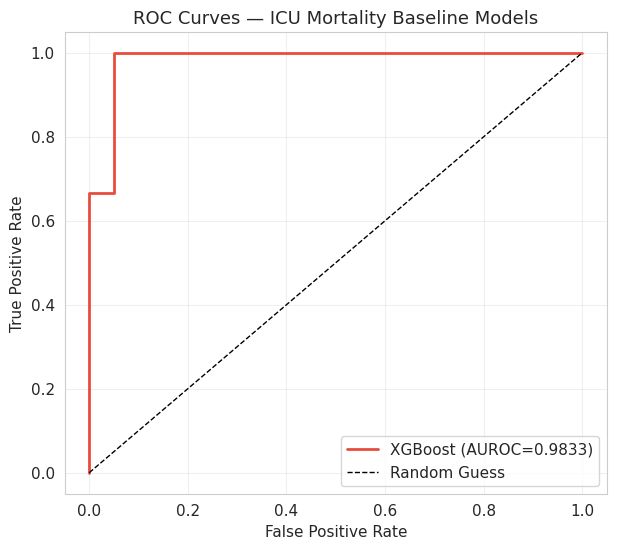

In [57]:
# Thêm kết quả Benchmark Bi-LSTM để so sánh
all_results["Bi-LSTM (Benchmark)"] = {
    "AUROC": 0.9221, "AUPRC": 0.7048, "Accuracy": 0.9088,
    "F1": 0.6207, "Sensitivity": 0.6728, "Specificity": 0.9382,
    "PPV": 0.5761, "NPV": 0.9583, "Threshold": 0.5
}

metrics_keys = ["AUROC", "AUPRC", "Accuracy", "F1", "Sensitivity", "Specificity"]

# 1. Tạo Bảng DataFrame So Sánh
rows = [{"Model": k, **{m: round(v[m], 4) for m in metrics_keys}} for k, v in all_results.items()]
df_compare = pd.DataFrame(rows).set_index("Model")
display(df_compare)

# Lưu CSV
df_compare.to_csv(os.path.join(OUT_DIR, "baseline_comparison.csv"))

# 2. Vẽ Đường Cong ROC
plt.figure(figsize=(7, 6))
colors = ["#e74c3c", "#3498db"]
for i, (name, y_true, y_prob) in enumerate(roc_data):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2, label=f"{name} (AUROC={auc:.4f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — ICU Mortality Baseline Models")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(os.path.join(OUT_DIR, "roc_curves.png"), dpi=150)
plt.show()